# LivingThings_Assignment 

## Problem Statement

Living Things has installed IoT-enabled HVAC/AC devices across multiple locations. These devices continuously send telemetry (sensor) data such as room temperature, ambient temperature, power consumption, compressor status, and operating mode.
The company wants you to analyze this time-series data to understand device performance, identify anomalies, and generate actionable business insights that can help improve energy efficiency and operational reliability.

1) Objective

2) Code

3) Observation

4) Business Insight

# Data Loading & Understanding

Load the dataset and understand its structure, size, columns, and data types.

Observation

The dataset contains telemetry data collected from multiple HVAC devices. The data includes device information, timestamps, room temperature, ambient temperature, compressor status, power consumption, and operating mode.

Initial exploration showed that the dataset contains multiple devices and time-series observations recorded at 15-minute intervals.


In [8]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load the Dataset

df = pd.read_csv(r"C:\Users\akash\Downloads\device_telemetry.csv")
df

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode
0,DVC-103,2026-06-06 03:15:00,25.74,26.0,25.74,0,49.0,OFF
1,DVC-102,2026-06-14 20:15:00,23.96,24.0,31.83,1,1420.6,COOL
2,DVC-101,2026-06-14 16:45:00,24.56,24.0,37.48,0,42.6,FAN
3,DVC-103,2026-06-01 03:30:00,26.04,26.0,25.88,0,52.1,OFF
4,DVC-102,2026-06-13 19:00:00,24.44,24.0,33.47,0,17.5,FAN
...,...,...,...,...,...,...,...,...
6465,DVC-101,2026-06-14 16:15:00,24.43,24.0,36.92,1,1507.1,COOL
6466,DVC-104,2026-06-03 06:45:00,26.43,26.0,28.78,0,42.1,OFF
6467,DVC-105,2026-06-01 20:45:00,24.55,24.0,31.64,0,55.9,FAN
6468,DVC-103,2026-06-14 16:30:00,24.44,24.0,36.24,0,45.6,FAN


In [10]:
df.shape

(6470, 8)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6470 entries, 0 to 6469
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   device_id         6470 non-null   object 
 1   timestamp         6470 non-null   object 
 2   room_temp_c       6470 non-null   float64
 3   setpoint_c        6470 non-null   float64
 4   ambient_temp_c    6470 non-null   float64
 5   compressor_state  6470 non-null   int64  
 6   power_watt        6470 non-null   float64
 7   mode              6470 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 404.5+ KB


In [12]:
df.describe()

,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt
count,6470.000000,6470.000000,6470.000000,6470.000000,6470.000000
mean,24.907362,25.002782,30.980975,0.352396,515.042875
std,5.240202,1.000073,4.289170,0.477753,655.594466
min,-99.000000,24.000000,23.050000,0.000000,8.000000
25%,24.310000,24.000000,26.802500,0.000000,42.425000
50%,24.795000,26.000000,30.980000,0.000000,52.800000
75%,25.880000,26.000000,35.190000,1.000000,1285.975000
max,85.000000,26.000000,38.740000,1.000000,5024.600000


# Data Cleaning

In [13]:
df.duplicated().sum()

np.int64(32)

In [14]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Convert timestamp

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

C:\Users\akash\AppData\Local\Temp\ipykernel_13196\614601148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp"] = pd.to_datetime(df["timestamp"])


In [ ]:
df = df.sort_values("timestamp")

# Feature Engineering

In [20]:
df["date"] = df["timestamp"].dt.date

In [21]:
df["hour"] = df["timestamp"].dt.hour

In [22]:
df["day"] = df["timestamp"].dt.day_name()

In [23]:
df

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,date,hour,day
3120,DVC-105,2026-06-01 00:00:00,26.86,26.0,26.49,0,46.4,OFF,2026-06-01,0,Monday
5703,DVC-103,2026-06-01 00:00:00,26.99,26.0,26.98,0,41.9,OFF,2026-06-01,0,Monday
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,2026-06-01,0,Monday
5002,DVC-102,2026-06-01 00:00:00,27.20,26.0,26.97,0,39.5,OFF,2026-06-01,0,Monday
1441,DVC-104,2026-06-01 00:00:00,26.98,26.0,27.09,0,31.8,OFF,2026-06-01,0,Monday
...,...,...,...,...,...,...,...,...,...,...,...
5305,DVC-101,2026-06-14 23:45:00,26.67,26.0,26.73,0,47.0,OFF,2026-06-14,23,Sunday
2032,DVC-102,2026-06-14 23:45:00,25.71,26.0,27.22,0,39.8,OFF,2026-06-14,23,Sunday
3300,DVC-103,2026-06-14 23:45:00,25.79,26.0,27.28,0,42.3,OFF,2026-06-14,23,Sunday
5009,DVC-105,2026-06-14 23:45:00,25.95,26.0,27.10,0,51.9,OFF,2026-06-14,23,Sunday


# Device Count

In [28]:
df["device_id"].value_counts()

device_id
DVC-101    1322
DVC-105    1320
DVC-102    1313
DVC-104    1313
DVC-103    1170
Name: count, dtype: int64

In [30]:
df["room_temp_c"].describe()

count    6438.00000
mean       24.90634
std         5.25274
min       -99.00000
25%        24.31000
50%        24.79000
75%        25.88000
max        85.00000
Name: room_temp_c, dtype: float64

In [31]:
df[(df["room_temp_c"] < 10) |(df["room_temp_c"] > 50)]

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,date,hour,day
446,DVC-101,2026-06-02 11:15:00,-99.0,24.0,33.74,1,1540.9,COOL,2026-06-02,11,Tuesday
5775,DVC-101,2026-06-02 15:15:00,85.0,24.0,37.58,0,46.3,FAN,2026-06-02,15,Tuesday
2656,DVC-104,2026-06-03 09:30:00,85.0,24.0,31.39,1,1388.5,COOL,2026-06-03,9,Wednesday
3364,DVC-104,2026-06-04 15:45:00,85.0,24.0,36.46,0,58.1,FAN,2026-06-04,15,Thursday
2973,DVC-101,2026-06-04 23:45:00,0.0,26.0,26.29,0,48.9,OFF,2026-06-04,23,Thursday
1099,DVC-101,2026-06-05 03:30:00,-99.0,26.0,25.37,0,44.1,OFF,2026-06-05,3,Friday
4898,DVC-102,2026-06-05 14:15:00,0.0,24.0,37.54,0,40.2,FAN,2026-06-05,14,Friday
148,DVC-105,2026-06-05 16:45:00,-99.0,24.0,37.17,1,1279.6,COOL,2026-06-05,16,Friday
5480,DVC-101,2026-06-06 04:00:00,85.0,26.0,24.11,0,72.7,OFF,2026-06-06,4,Saturday
1585,DVC-103,2026-06-06 05:30:00,85.0,26.0,27.55,0,46.6,OFF,2026-06-06,5,Saturday


In [32]:
df["room_temp_clean"] = df["room_temp_c"]

In [33]:
df.loc[
    (df["room_temp_clean"] < 10) |
    (df["room_temp_clean"] > 50),
    "room_temp_clean"
] = np.nan

In [ ]:
df["room_temp_clean"] = (
    df["room_temp_clean"]
    .interpolate()
)

# EDA (Exploratory Data Analysis)

# Room Temperature Trend

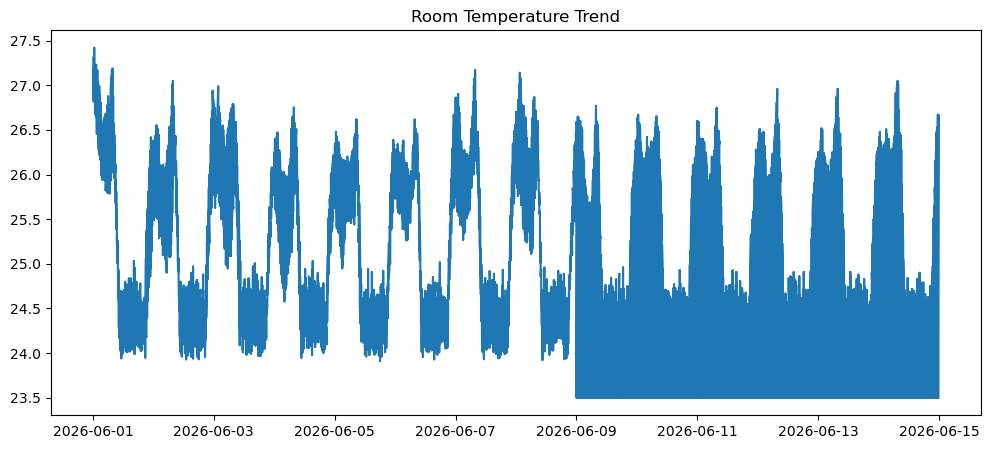

In [35]:
plt.figure(figsize = (12,5))

plt.plot(df["timestamp"],
         df["room_temp_clean"])

plt.title("Room Temperature Trend")
plt.show()

# Average Temperature by Device

In [64]:
avg_temp = df.groupby("device_id")["room_temp_clean"].mean()
avg_temp

device_id
DVC-101    25.142456
DVC-102    25.154492
DVC-103    25.147832
DVC-104    24.526506
DVC-105    25.220668
Name: room_temp_clean, dtype: float64

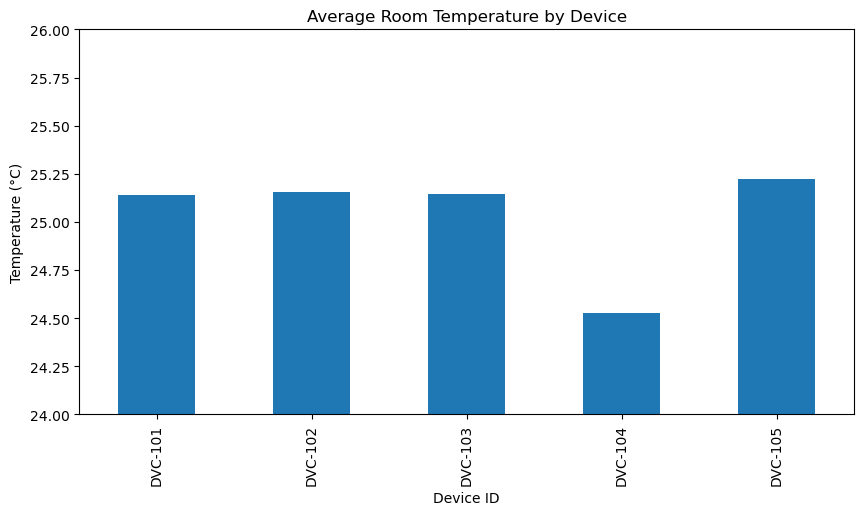

In [65]:
plt.figure(figsize=(10,5))
avg_temp.plot(kind="bar")
plt.title("Average Room Temperature by Device")
plt.xlabel("Device ID")
plt.ylabel("Temperature (°C)")
plt.ylim(24,26)
plt.show()

# Average Power Consumption by Device

In [66]:
avg_power = df.groupby("device_id")["power_watt"].mean()
avg_power

device_id
DVC-101    543.319289
DVC-102    508.110739
DVC-103    490.867009
DVC-104    507.695887
DVC-105    525.668409
Name: power_watt, dtype: float64

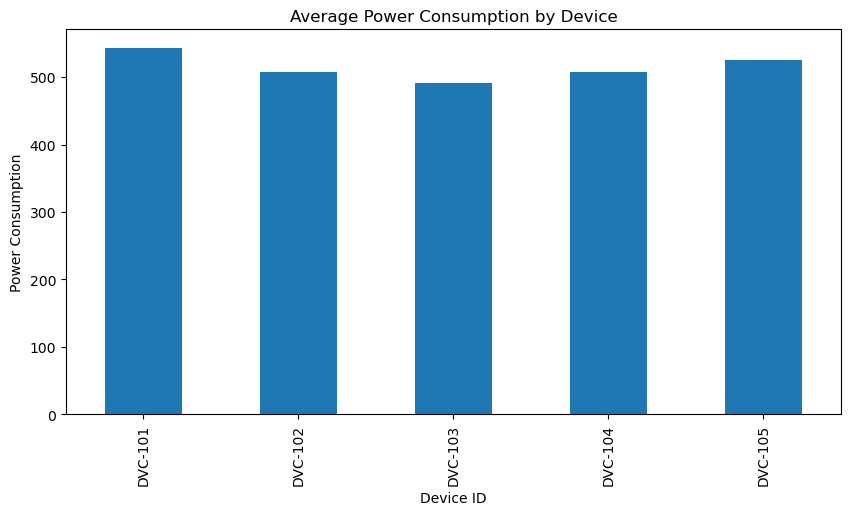

In [67]:
plt.figure(figsize=(10,5))
avg_power.plot(kind="bar")
plt.title("Average Power Consumption by Device")
plt.xlabel("Device ID")
plt.ylabel("Power Consumption")
plt.show()

# Compressor Runtime Analysis

In [68]:
runtime_hours = df[df["compressor_state"]==1].groupby("device_id").size()*15/60
runtime_hours

device_id
DVC-101    114.75
DVC-102    115.75
DVC-103    100.50
DVC-104    116.50
DVC-105    120.50
dtype: float64

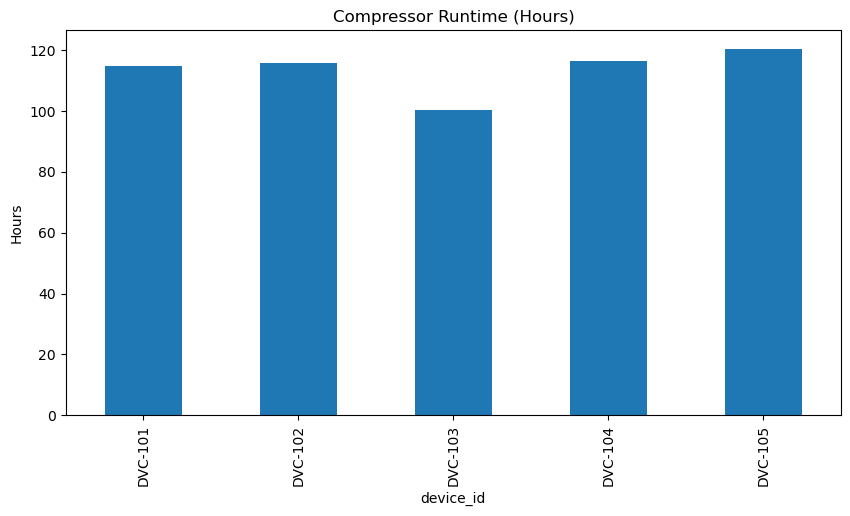

In [69]:
plt.figure(figsize=(10,5))

runtime_hours.plot(kind="bar")

plt.title("Compressor Runtime (Hours)")
plt.ylabel("Hours")

plt.show()

# Temperature Deviation from Setpoint

In [70]:
df["temp_gap"] = (df["room_temp_clean"] - df["setpoint_c"])

In [73]:
temp_gap = (df.groupby("device_id")["temp_gap"].mean())
temp_gap

device_id
DVC-101    0.150847
DVC-102    0.152200
DVC-103    0.131551
DVC-104   -0.478081
DVC-105    0.228255
Name: temp_gap, dtype: float64

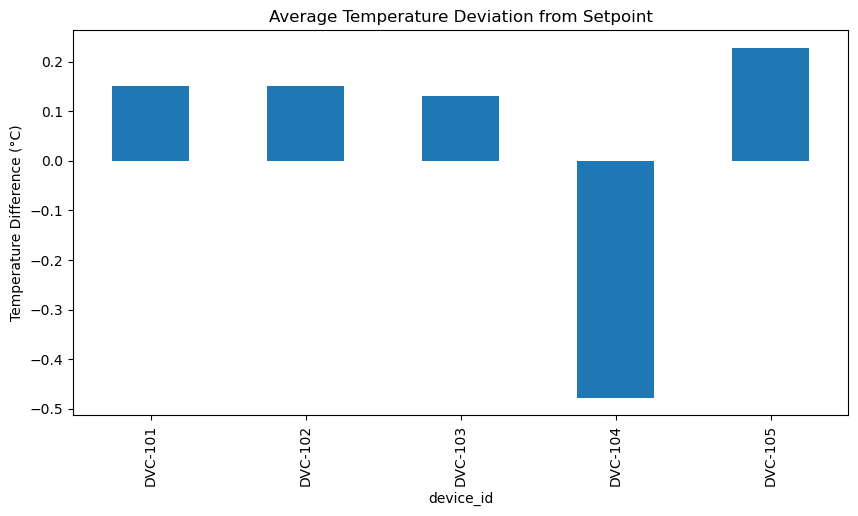

In [78]:
plt.figure(figsize=(10,5))

temp_gap.plot(kind="bar")

plt.title("Average Temperature Deviation from Setpoint")
plt.ylabel("Temperature Difference (°C)")

plt.show()

# Energy Consumption Analysis

In [77]:
df["energy_kwh"] = (df["power_watt"]/1000) * 0.25

energy = (df.groupby("device_id")["energy_kwh"].sum())
energy

device_id
DVC-101    179.567025
DVC-102    166.787350
DVC-103    143.578600
DVC-104    166.651175
DVC-105    173.470575
Name: energy_kwh, dtype: float64

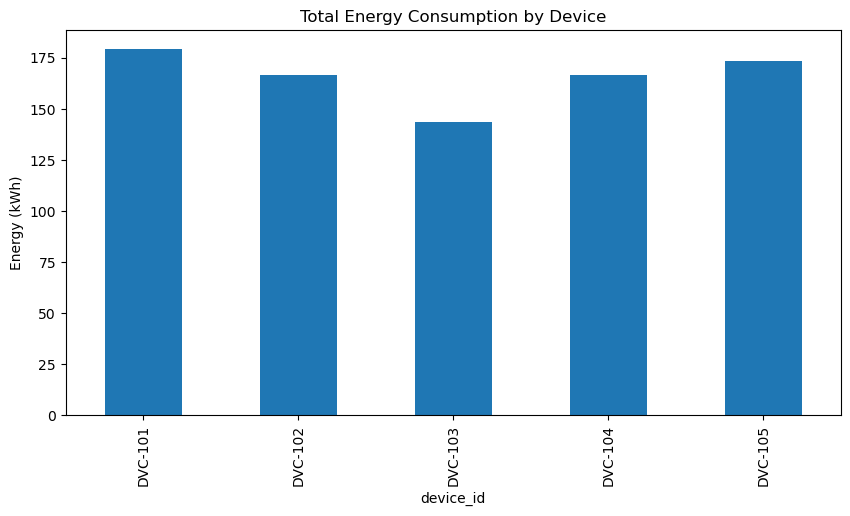

In [76]:
plt.figure(figsize=(10,5))

energy.plot(kind="bar")

plt.title("Total Energy Consumption by Device")
plt.ylabel("Energy (kWh)")

plt.show()

# Conclusion

The dataset contained duplicate records and sensor anomalies that were successfully addressed through data cleaning.

1) Room temperatures remained generally stable within the expected HVAC operating range.

2) Energy consumption and compressor runtime varied considerably across devices.

3) Several devices showed larger temperature deviations from their configured setpoints.

4) Power spikes and offline periods were detected, indicating potential operational issues.